# Métodos Numéricos — Problema das Duas Vigas

Este notebook determina a distância horizontal `x` entre as paredes de um galpão usando os métodos da **Bisseção**, **Newton-Raphson** e **Secante**. Ele é autocontido: execute as células na ordem para reproduzir todos os resultados, tabelas e gráficos.

**Dados:** duas vigas de comprimentos `30 m` e `20 m` se cruzam a `8 m` do chão.

## 1. Modelagem matemática

Se `x` é a largura do galpão, as alturas em que as vigas alcançam as paredes são

$$a = \sqrt{30^2-x^2}, \qquad b = \sqrt{20^2-x^2}.$$

Para vigas cruzadas, a altura de cruzamento `h` satisfaz

$$\frac{1}{h}=\frac{1}{a}+\frac{1}{b}.$$

Com `h=8`, procuramos a raiz de

$$f(x)=\frac{1}{\sqrt{900-x^2}}+\frac{1}{\sqrt{400-x^2}}-\frac{1}{8}=0.$$

Como a menor viga mede `20 m`, o domínio físico é `0 ≤ x < 20`. Para Newton-Raphson,

$$f'(x)=\frac{x}{(900-x^2)^{3/2}}+\frac{x}{(400-x^2)^{3/2}}.$$

In [1]:
import math

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.precision", 12)

L1, L2, h = 30.0, 20.0, 8.0
LIMITE_FISICO = min(L1, L2)
TOL_F = 1e-10
TOL_X = 1e-10
MAX_ITER = 100


def no_dominio(x):
    return 0.0 <= x < LIMITE_FISICO


def f(x):
    """Função cuja raiz fornece a largura x do galpão."""
    if not no_dominio(x):
        raise ValueError(f"x={x} está fora do domínio físico [0, {LIMITE_FISICO}).")
    return 1 / math.sqrt(L1**2 - x**2) + 1 / math.sqrt(L2**2 - x**2) - 1 / h


def df(x):
    """Derivada de f para o método de Newton-Raphson."""
    if not no_dominio(x):
        raise ValueError(f"x={x} está fora do domínio físico [0, {LIMITE_FISICO}).")
    return x / (L1**2 - x**2) ** 1.5 + x / (L2**2 - x**2) ** 1.5


print(f"Domínio físico: 0 ≤ x < {LIMITE_FISICO:g} m")
print(f"f(0) = {f(0):.12f}")
print(f"f(19,9) = {f(19.9):.12f}")

Domínio físico: 0 ≤ x < 20 m
f(0) = -0.041666666667
f(19,9) = 0.420170156547


Como `f(0) < 0` e `f(19,9) > 0`, existe ao menos uma raiz no intervalo `[0, 19,9]`. Os algoritmos abaixo registram cada iteração, o que permite conferir os cálculos e comparar a convergência.

In [2]:
def bissecao(funcao, a, b, tol_f=TOL_F, tol_x=TOL_X, max_iter=MAX_ITER):
    """Retorna a aproximação e o histórico do método da bisseção."""
    if not (no_dominio(a) and no_dominio(b) and a < b):
        raise ValueError("O intervalo inicial deve estar no domínio físico e ter a < b.")
    fa, fb = funcao(a), funcao(b)
    if fa * fb > 0:
        raise ValueError("A bisseção exige mudança de sinal no intervalo inicial.")

    historico = []
    for k in range(1, max_iter + 1):
        x = (a + b) / 2
        fx = funcao(x)
        historico.append({"k": k, "a": a, "b": b, "x_k": x, "f(x_k)": fx,
                          "|f(x_k)|": abs(fx), "largura_intervalo": b - a})
        if abs(fx) <= tol_f or (b - a) / 2 <= tol_x:
            return x, pd.DataFrame(historico)
        if fa * fx < 0:
            b, fb = x, fx
        else:
            a, fa = x, fx
    raise RuntimeError("Bisseção não convergiu no número máximo de iterações.")


def newton_raphson(funcao, derivada, x0, tol_f=TOL_F, tol_x=TOL_X, max_iter=MAX_ITER):
    """Retorna a aproximação e o histórico do método de Newton-Raphson."""
    if not no_dominio(x0):
        raise ValueError("O chute inicial deve pertencer ao domínio físico.")

    x = x0
    historico = []
    for k in range(1, max_iter + 1):
        fx, dfx = funcao(x), derivada(x)
        if abs(dfx) < 1e-15:
            raise ZeroDivisionError("Derivada muito próxima de zero.")
        x_novo = x - fx / dfx
        if not no_dominio(x_novo):
            raise ValueError("A iteração de Newton saiu do domínio físico.")
        f_novo = funcao(x_novo)
        historico.append({"k": k, "x_k": x, "x_{k+1}": x_novo,
                          "f(x_{k+1})": f_novo, "|f(x_{k+1})|": abs(f_novo),
                          "|Δx|": abs(x_novo - x)})
        if abs(f_novo) <= tol_f or abs(x_novo - x) <= tol_x:
            return x_novo, pd.DataFrame(historico)
        x = x_novo
    raise RuntimeError("Newton-Raphson não convergiu no número máximo de iterações.")


def secante(funcao, x0, x1, tol_f=TOL_F, tol_x=TOL_X, max_iter=MAX_ITER):
    """Retorna a aproximação e o histórico do método da secante."""
    if not (no_dominio(x0) and no_dominio(x1) and x0 != x1):
        raise ValueError("Os chutes iniciais devem ser distintos e estar no domínio físico.")

    historico = []
    for k in range(1, max_iter + 1):
        f0, f1 = funcao(x0), funcao(x1)
        denominador = f1 - f0
        if abs(denominador) < 1e-15:
            raise ZeroDivisionError("Denominador da secante muito próximo de zero.")
        x2 = x1 - f1 * (x1 - x0) / denominador
        if not no_dominio(x2):
            raise ValueError("A iteração da secante saiu do domínio físico.")
        f2 = funcao(x2)
        historico.append({"k": k, "x_{k-1}": x0, "x_k": x1, "x_{k+1}": x2,
                          "f(x_{k+1})": f2, "|f(x_{k+1})|": abs(f2),
                          "|Δx|": abs(x2 - x1)})
        if abs(f2) <= tol_f or abs(x2 - x1) <= tol_x:
            return x2, pd.DataFrame(historico)
        x0, x1 = x1, x2
    raise RuntimeError("Secante não convergiu no número máximo de iterações.")

## 2. Execução dos três métodos

A tolerância adotada é `10⁻¹⁰`, tanto para o resíduo quanto para a variação de `x` quando aplicável.

In [3]:
raiz_bis, hist_bis = bissecao(f, 0.0, 19.9)
raiz_newton, hist_newton = newton_raphson(f, df, 15.0)
raiz_sec, hist_sec = secante(f, 10.0, 19.0)

resultados = pd.DataFrame(
    [
        ["Bisseção", "[0, 19,9]", len(hist_bis), raiz_bis, abs(f(raiz_bis))],
        ["Newton-Raphson", "x₀ = 15", len(hist_newton), raiz_newton, abs(f(raiz_newton))],
        ["Secante", "x₀ = 10; x₁ = 19", len(hist_sec), raiz_sec, abs(f(raiz_sec))],
    ],
    columns=["Método", "Dados iniciais", "Iterações", "x (m)", "Resíduo |f(x)|"],
)
resultados

,Método,Dados iniciais,Iterações,x (m),Resíduo |f(x)|
0,Bisseção,"[0, 19,9]",28,16.212125899270,0.000000000029
1,Newton-Raphson,x₀ = 15,4,16.212125897080,0.000000000004
2,Secante,x₀ = 10; x₁ = 19,9,16.212125896917,0.000000000003


## 3. Histórico das iterações

As tabelas permitem auditar cada aproximação. A última linha de cada uma satisfaz o critério de parada.

In [4]:
print("Bisseção")
display(hist_bis)

print("Newton-Raphson")
display(hist_newton)

print("Secante")
display(hist_sec)

Bisseção


,k,a,b,x_k,f(x_k),|f(x_k)|,largura_intervalo
0,1,0.000000000000,19.900000000000,9.950000000000,-0.032027401057,0.032027401057,19.900000000000
1,2,9.950000000000,19.900000000000,14.925000000000,-0.011461044101,0.011461044101,9.950000000000
2,3,14.925000000000,19.900000000000,17.412500000000,0.017570877216,0.017570877216,4.975000000000
3,4,14.925000000000,17.412500000000,16.168750000000,-0.000477415729,0.000477415729,2.487500000000
4,5,16.168750000000,17.412500000000,16.790625000000,0.007251715956,0.007251715956,1.243750000000
5,6,16.168750000000,16.790625000000,16.479687500000,0.003134736080,0.003134736080,0.621875000000
6,7,16.168750000000,16.479687500000,16.324218750000,0.001272140227,0.001272140227,0.310937500000
7,8,16.168750000000,16.324218750000,16.246484375000,0.000383950527,0.000383950527,0.155468750000
8,9,16.168750000000,16.246484375000,16.207617187500,-0.000050001382,0.000050001382,0.077734375000
9,10,16.207617187500,16.246484375000,16.227050781250,0.000166147095,0.000166147095,0.038867187500


Newton-Raphson


,k,x_k,x_{k+1},f(x_{k+1}),|f(x_{k+1})|,|Δx|
0,1,15.000000000000,16.488411344893,0.003242849061,0.003242849061,1.488411344893
1,2,16.488411344893,16.227218895638,0.000168024123,0.000168024123,0.261192449255
2,3,16.227218895638,16.212170456845,0.000000494610,0.000000494610,0.015048438793
3,4,16.212170456845,16.212125897080,0.000000000004,0.000000000004,0.000044559765


Secante


,k,x_{k-1},x_k,x_{k+1},f(x_{k+1}),|f(x_{k+1})|,|Δx|
0,1,10.000000000000,19.000000000000,12.608160230943,-0.023853852391,0.023853852391,6.391839769057
1,2,19.000000000000,12.608160230943,14.102157776963,-0.016722087295,0.016722087295,1.493997546020
2,3,12.608160230943,14.102157776963,17.605183612191,0.021542935369,0.021542935369,3.503025835227
3,4,14.102157776963,17.605183612191,15.633005003348,-0.005780360459,0.005780360459,1.972178608842
4,5,17.605183612191,15.633005003348,16.050227849371,-0.001742057708,0.001742057708,0.417222846022
5,6,15.633005003348,16.050227849371,16.230210956038,0.000201451758,0.000201451758,0.179983106667
6,7,16.050227849371,16.230210956038,16.211555058612,-0.000006335441,0.000006335441,0.018655897426
7,8,16.230210956038,16.211555058612,16.212123877766,-0.000000022410,0.000000022410,0.000568819154
8,9,16.211555058612,16.212123877766,16.212125896917,0.000000000003,0.000000000003,0.000002019151


## 4. Visualização da função e convergência

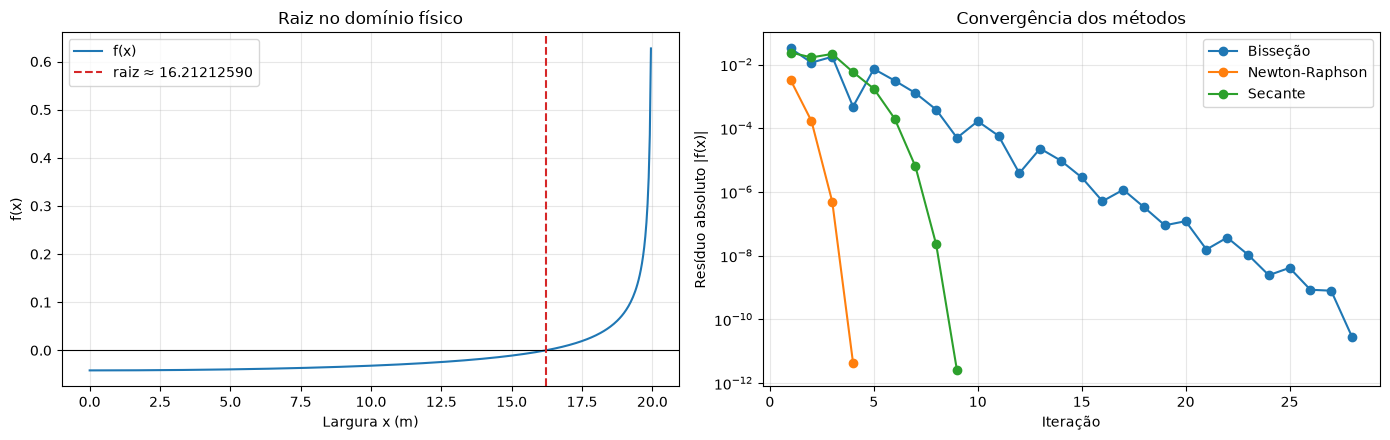

In [5]:
xs = [i * 19.95 / 500 for i in range(501)]
ys = [f(x) for x in xs]

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].plot(xs, ys, color="#1f77b4", label="f(x)")
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].axvline(raiz_newton, color="#d62728", linestyle="--", label=f"raiz ≈ {raiz_newton:.8f}")
axes[0].set(xlabel="Largura x (m)", ylabel="f(x)", title="Raiz no domínio físico")
axes[0].grid(alpha=0.3)
axes[0].legend()

series = [
    ("Bisseção", hist_bis["|f(x_k)|"], "#1f77b4"),
    ("Newton-Raphson", hist_newton["|f(x_{k+1})|"], "#ff7f0e"),
    ("Secante", hist_sec["|f(x_{k+1})|"], "#2ca02c"),
]
for nome, residuos, cor in series:
    axes[1].semilogy(range(1, len(residuos) + 1), residuos, marker="o", label=nome, color=cor)
axes[1].set(xlabel="Iteração", ylabel="Resíduo absoluto |f(x)|", title="Convergência dos métodos")
axes[1].grid(alpha=0.3, which="both")
axes[1].legend()

plt.tight_layout()
plt.show()

## 5. Conclusão

Os três métodos retornam a mesma largura, aproximadamente **`16,212125897 m`**. A Bisseção é a alternativa mais robusta, pois preserva a raiz dentro de um intervalo com mudança de sinal, mas requer mais iterações. Newton-Raphson converge mais rapidamente para o chute adotado (`x₀=15`), ao custo de exigir a derivada e um chute adequado. A Secante dispensa a derivada e apresenta desempenho intermediário.

Uma verificação física pode ser feita substituindo a largura encontrada nas alturas `a` e `b` e na equação da altura de cruzamento.

In [6]:
x = raiz_newton
a = math.sqrt(L1**2 - x**2)
b = math.sqrt(L2**2 - x**2)
h_calculada = 1 / (1 / a + 1 / b)

print(f"Largura do galpão: x = {x:.12f} m")
print(f"Altura na parede da viga de 30 m: a = {a:.12f} m")
print(f"Altura na parede da viga de 20 m: b = {b:.12f} m")
print(f"Altura de cruzamento verificada: h = {h_calculada:.12f} m")
assert math.isclose(h_calculada, 8.0, rel_tol=0, abs_tol=1e-9)
print("Verificação física aprovada.")

Largura do galpão: x = 16.212125897080 m
Altura na parede da viga de 30 m: a = 25.242166584848 m
Altura na parede da viga de 20 m: b = 11.711830510097 m
Altura de cruzamento verificada: h = 7.999999999724 m
Verificação física aprovada.
